# Health & Nutrition Analysis

## Introduction
This dataset contains health and nutritional information of 6,000 individuals.
The analysis explores BMI patterns, calorie consumption, diet preferences,
protein intake, and eating habits across different health groups.

## Dataset
- Source: Kaggle
- Records: 6,000 individuals
- Format: Excel (.xlsx)

## Skills Used
- Python (Pandas)
- Data Visualization (Matplotlib)
- Excel Report Generation

Gender
Female    25.517233
Male      26.666321
Other     26.067589
Name: BMI, dtype: float64
Activity_Level
Athlete              3095.928747
Lightly Active       2360.662569
Moderately Active    2576.963552
Sedentary            2135.378615
Very Active          2864.262887
Name: Daily_Calorie_Consumed, dtype: float64
Diet_Type
Balanced         1536
High Protein     1076
Vegetarian       1055
Mediterranean    1027
Keto              721
Vegan             585
Name: count, dtype: int64
Health_Status
Healthy        111.550556
Obese          139.417007
Overweight     131.591600
Underweight     72.971429
Name: Protein_Intake_g, dtype: float64
People overeating are : 4667
People undereating are: 1329
Report saved.
Charts inserted and saved Succesful


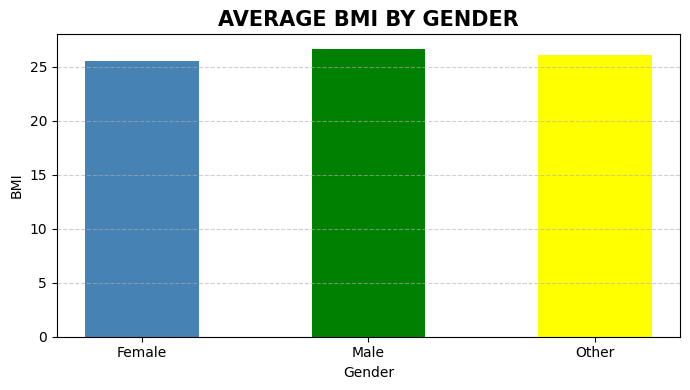

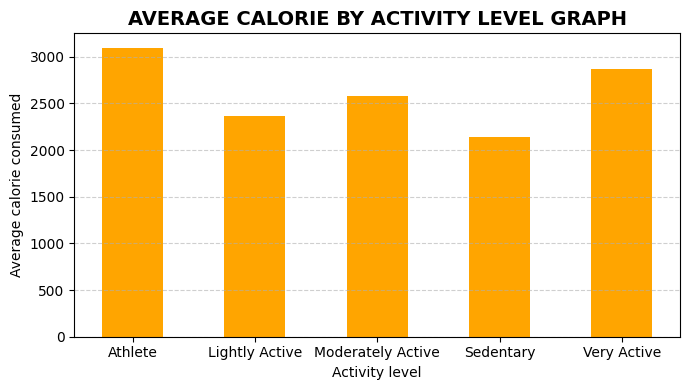

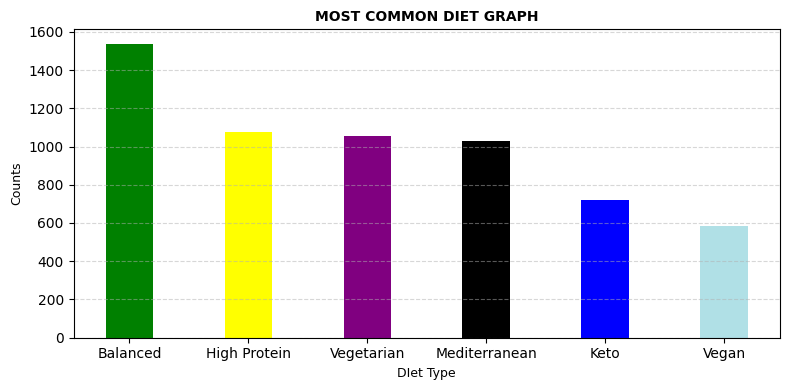

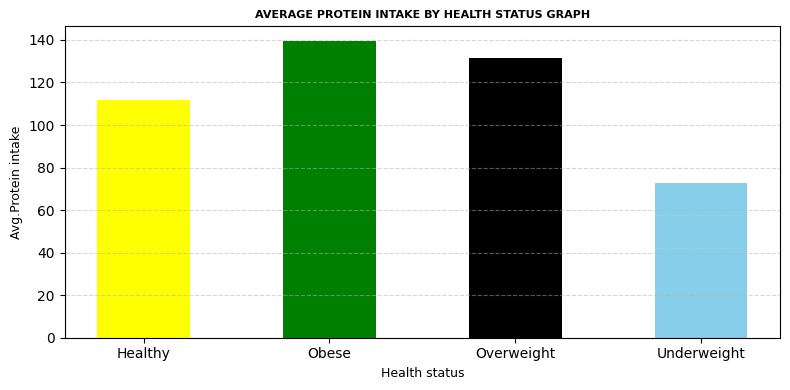

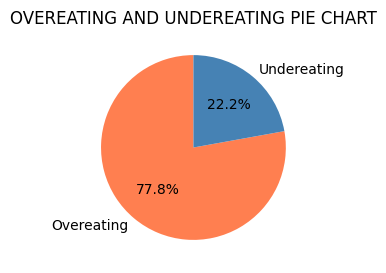

In [6]:

#load data
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
df = pd.read_excel("hddataa.xlsx")
#Analysis(Average BMI by gender)
print(df.groupby("Gender")["BMI"].mean())
#Average Calories consumed by activity level
print(df.groupby("Activity_Level")["Daily_Calorie_Consumed"].mean())
#Most Common Diet type
print(df["Diet_Type"].value_counts(ascending=False))
#Average protein Intake by health status
print(df.groupby("Health_Status")["Protein_Intake_g"].mean())
#Who is eating more than their Daily Requirements
overeating = df[df["Daily_Calorie_Consumed"] > df["Daily_Calorie_Requirement"]]
print(f"People overeating are : {len(overeating)}")
#People undereating than their Daily requirements
undereating = df[df["Daily_Calorie_Requirement"] > df["Daily_Calorie_Consumed"]]
print(f"People undereating are: {len(undereating)}")

#Prepare Analysis Results

#1.BMI by gender
BMI_by_gender = df.groupby("Gender")["BMI"].mean().reset_index()
BMI_by_gender.columns = ["Gender", "Average BMI"]

#2.Average Calorie Consumed by Activity level
A_Calorie_act = df.groupby("Activity_Level")["Daily_Calorie_Consumed"].mean().reset_index()
A_Calorie_act.columns = ["Activity level", "Average Calorie consumed"]

#3.Most Common Diet Type
Common_diet = df["Diet_Type"].value_counts(ascending=False).reset_index()
Common_diet.columns = ["Diet type", "Counts"]

#4.Average Protein Intake by Health status
A_Protein_health = df.groupby("Health_Status")["Protein_Intake_g"].mean().reset_index()
A_Protein_health.columns = ["Health status", "Average Protein intake"]

#5.Over eating vs under eating
overeating = df[df["Daily_Calorie_Consumed"] > df["Daily_Calorie_Requirement"]]
undereating = df[df["Daily_Calorie_Consumed"] < df["Daily_Calorie_Requirement"]]

eating_summary = pd.DataFrame({
    "Category": ["Overeating", "Undereating"],
    "Count": [len(overeating), len(undereating)]
})

# 6. Summary
summary = pd.DataFrame({
    "Metric": [
        "Total People",
        "Average BMI",
        "Most Common Diet",
        "People Overeating",
        "People Undereating"
    ],
    "Value": [
        len(df),
        round(df["BMI"].mean(), 2),
        df["Diet_Type"].value_counts().index[0],
        len(overeating),
        len(undereating)
    ]
})

# Save to Excel
with pd.ExcelWriter("health_analysis_report.xlsx") as writer:
    df.to_excel(writer, sheet_name="Raw Data", index=False)
    BMI_by_gender.to_excel(writer, sheet_name="BMI by Gender", index=False)
    A_Calorie_act.to_excel(writer, sheet_name="Calories by Activity", index=False)
    Common_diet.to_excel(writer, sheet_name="Diet Types", index=False)
    A_Protein_health.to_excel(writer, sheet_name="Protein by Health", index=False)
    eating_summary.to_excel(writer, sheet_name="Eating Habits", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)

print("Report saved.")



#CHARTS
#Average Bmi by gender
BMI_by_gender = df.groupby("Gender")["BMI"].mean()

plt.figure(figsize=(7, 4))
plt.bar(BMI_by_gender.index, BMI_by_gender.values, width=0.5,color=["steelblue","green","yellow"])
plt.title("AVERAGE BMI BY GENDER", fontsize=15, fontweight="bold")
plt.xlabel("Gender", fontsize=10)
plt.ylabel("BMI", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("BMI_Chart.png",dpi=300, bbox_inches="tight")


#Average calories consumed by activity level
Av_by_act_lvl=df.groupby("Activity_Level")["Daily_Calorie_Consumed"].mean()

plt.figure(figsize=(7, 4))
plt.bar(Av_by_act_lvl.index, Av_by_act_lvl.values, width=0.5,color=["orange"])
plt.title("AVERAGE CALORIE BY ACTIVITY LEVEL GRAPH",fontsize=14,fontweight="bold")
plt.xlabel("Activity level",fontsize=10)
plt.ylabel("Average calorie consumed")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("Calorie_chart.png",dpi=150, bbox_inches="tight")


#Most common diet
Common_diet = df["Diet_Type"].value_counts(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(Common_diet.index, Common_diet.values, width=0.4,color=["green","yellow","purple","black","blue","powderblue" ])
plt.title("MOST COMMON DIET GRAPH", fontsize=10,fontweight="bold")
plt.xlabel("DIet Type", fontsize=9)
plt.ylabel("Counts",fontsize=9)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Common_diet_chart.png",dpi=150, bbox_inches="tight")


#Average protein intake by health status
A_Protein_health = df.groupby("Health_Status")["Protein_Intake_g"].mean()

plt.figure(figsize=(8,4))
plt.bar(A_Protein_health.index, A_Protein_health.values, width=0.5,color=["yellow","green","black","skyblue"])
plt.title("AVERAGE PROTEIN INTAKE BY HEALTH STATUS GRAPH",fontsize=8,fontweight="bold")
plt.ylabel("Avg.Protein intake",fontsize=9)
plt.xlabel("Health status",fontsize=9)
plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Protein_intke_chart.png",dpi=150, bbox_inches="tight")

#Overeating and undereating Pie chat.
labels = ["Overeating", "Undereating"]
sizes = [len(overeating), len(undereating)]
colors = ["coral", "steelblue"]
plt.figure(figsize=(7,3))
plt.pie(sizes,labels=labels,colors=colors,autopct="%1.1f%%",startangle=90)
plt.title("OVEREATING AND UNDEREATING PIE CHART")
plt.savefig("Over_and_Undereating_chart.png",dpi=150, bbox_inches="tight")


wb = load_workbook("health_analysis_report.xlsx")
ws = wb.create_sheet("Health Charts")

img1 = Image("BMI_Chart.png")
img2 = Image("Calorie_chart.png")
img3 = Image("Common_diet_chart.png")
img4 = Image("Protein_intke_chart.png")
img5 = Image("Over_and_Undereating_chart.png")

ws.add_image(img1, "A1")
ws.add_image(img2, "A60")
ws.add_image(img3, "A100")
ws.add_image(img4, "S60")
ws.add_image(img5, "V100")


wb.save("health_analysis_report.xlsx")
print("Charts inserted and saved Succesful")

## Data Overview
The dataset contains 6,000 records across 13 columns covering individual
health metrics including BMI, calorie intake, diet type, protein intake
and health status. The data was loaded from an Excel file with no
significant missing values, requiring minimal cleaning before analysis.

## Question 1 — Average BMI by Gender

**Finding:**
All three gender groups recorded an average BMI in the overweight range (25-29.9).
Males had the highest average BMI at 26.67, followed by Other at 26.07 and
Females at 25.51. This indicates that regardless of gender, the majority of
individuals in this dataset face potential health risks associated with being
overweight, suggesting a need for dietary and lifestyle interventions across
all groups.

## Question 2 — Average Calories Consumed by Activity Level

**Finding:**
From the findings Athletes have recorded the highest average daily calorie
intake at 3,095, followed by Very Active at 2,864, Moderately Active at 2,576,
Lightly Active at 2,360 and Sedentary individuals consuming the least at 2,135
calories. This confirms that calorie consumption increases proportionally with
physical activity level, which is consistent with the body's higher energy
demands during intense physical activity, thus indicating a clear pattern
exists between activity level and calorie consumption.

## Question 3 — Most Common Diet Type

**Finding:**
From the findings Balanced diet is the most preferred diet type among the
individuals, with 1,536 people following it. High Protein and Vegetarian diets
followed closely at 1,076 and 1,055 respectively, while Vegan was the least
preferred at 585. This indicates that most individuals gravitate toward flexible,
well-rounded eating patterns rather than restrictive diets such as Keto or Vegan.

## Question 4 — Average Protein Intake by Health Status

**Finding:**
Obese individuals recorded the highest average protein intake at 139.42g,
followed by Overweight at 131.59g, while Healthy individuals consumed a
moderate 111.55g. Underweight individuals had the lowest intake at just 72.97g.
Surprisingly, higher protein consumption does not correlate with better health
outcomes as Obese individuals consume the most protein yet have the worst health
status. This suggests that overall diet quality and calorie balance matters more
than protein intake alone, and thus personalized nutritional guidance is needed
across all health groups.

## Question 5 — Overeating vs Undereating

**Finding:**
A significant majority of individuals, 4,667 out of 6,000, consume more calories
than their daily requirement, representing 77.8% of the dataset. Only 1,329
individuals are undereating. Excessive calorie consumption at this scale poses
serious long term health risks including weight gain and obesity, while
undereating threatens basic energy needs and nutritional sufficiency. These
findings highlight an urgent need for structured dietary guidance to help
individuals align their calorie intake with their daily requirements.

## Overall Summary

This health analysis of 6,000 individuals reveals three critical insights.
First, all gender groups recorded an average BMI in the overweight range,
indicating widespread weight management challenges across the dataset.
Second, despite Balanced diet being the most preferred diet type, 77.8% of
individuals are consuming more calories than their daily requirement, suggesting
that diet preference alone does not translate to healthy eating habits. Finally,
Obese individuals surprisingly consume the most protein at 139.42g on average,
highlighting that calorie balance and overall diet quality matter more than any
single nutrient. These findings collectively point to an urgent need for
personalized nutritional education and structured dietary interventions across
all health groups.